In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import textalloc as ta
from scipy.cluster.hierarchy import dendrogram, leaves_list, linkage, optimal_leaf_ordering
from sklearn import set_config
from sklearn.metrics.pairwise import pairwise_distances

set_config(transform_output="pandas")

In [2]:
pca_analysis = pd.read_csv("03_pca_analysis.csv", index_col="name")
points = pd.read_csv("04_points.csv", index_col="name")["points"]

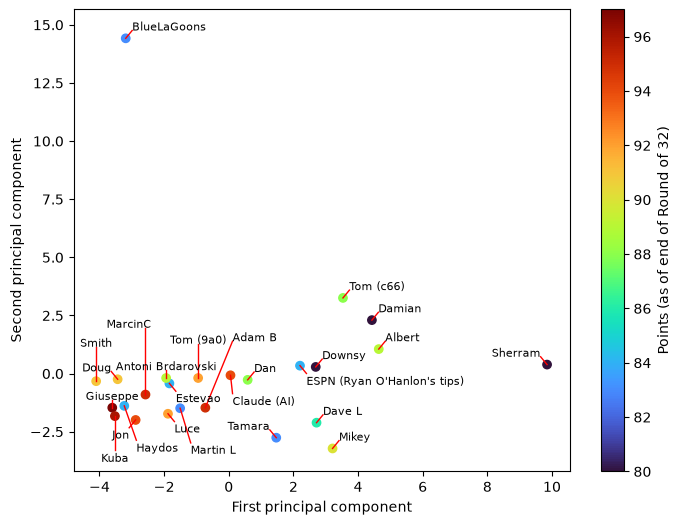

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
scattered = ax.scatter(
    list(pca_analysis["pca0"]), list(pca_analysis["pca1"]), c=list(points.loc[pca_analysis.index]), cmap="turbo"
)
cbar = fig.colorbar(scattered)
cbar.set_label("Points (as of end of Round of 32)")
ta.allocate(
    ax,
    list(pca_analysis["pca0"]),
    list(pca_analysis["pca1"]),
    list(pca_analysis.index),
    x_scatter=list(pca_analysis["pca0"]),
    y_scatter=list(pca_analysis["pca1"]),
    textsize=8,
)
ax.set_xlabel("First principal component")
ax.set_ylabel("Second principal component")
plt.show()

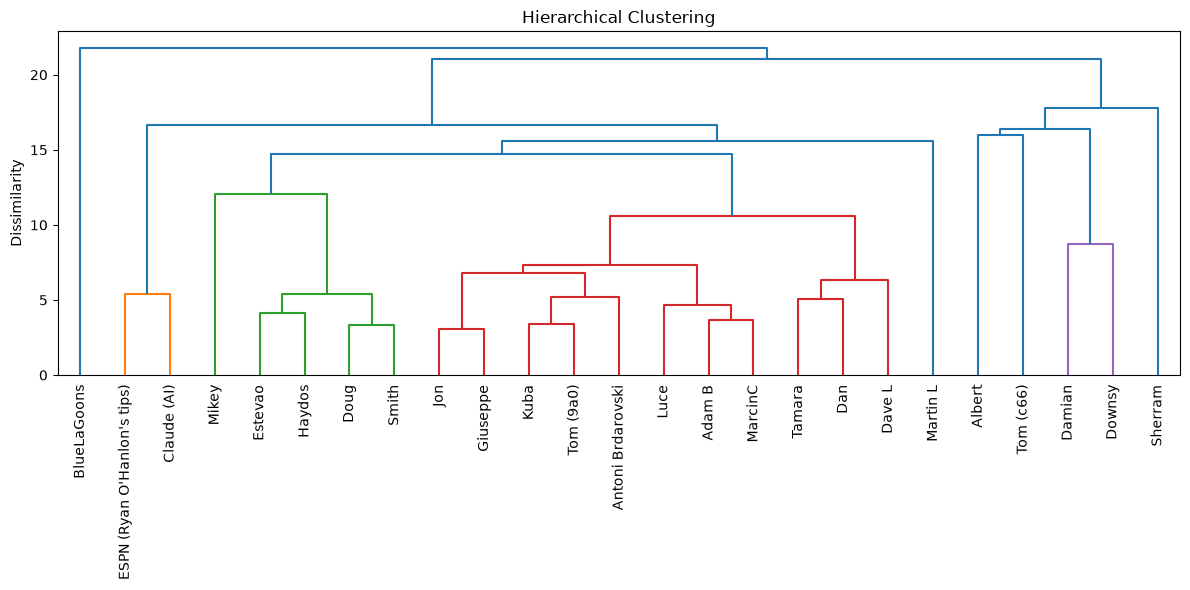

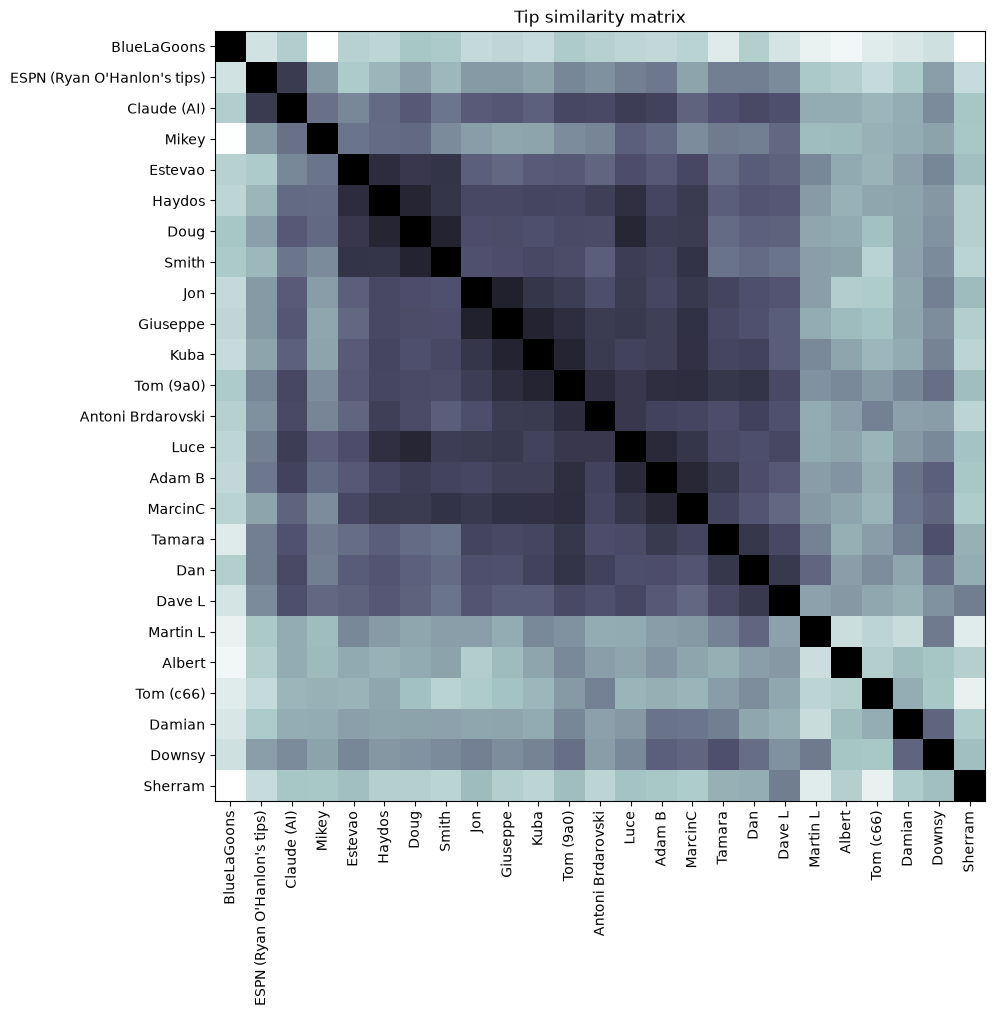

In [4]:
truncated = pca_analysis.iloc[:, :8]

linked_first = linkage(truncated, method="ward")
linked_optimal = optimal_leaf_ordering(linked_first, truncated)

plt.figure(figsize=(12, 6))
dendrogram(linked_optimal, labels=truncated.index, leaf_rotation=90, leaf_font_size=10, color_threshold=14)
plt.title("Hierarchical Clustering")
plt.ylabel("Dissimilarity")
plt.tight_layout()
plt.show()

ideal_ordering = truncated.index[leaves_list(linked_optimal)]
reordered = truncated.loc[ideal_ordering]
similarity_matrix = pairwise_distances(reordered)

fig, ax = plt.subplots(figsize=(10, 10))
cax = ax.imshow(similarity_matrix, cmap="bone")
ax.set_xticks(np.arange(len(ideal_ordering)))
ax.set_yticks(np.arange(len(ideal_ordering)))
ax.set_xticklabels(ideal_ordering, rotation=90, fontsize=10)
ax.set_yticklabels(ideal_ordering, fontsize=10)
ax.set_title("Tip similarity matrix")

plt.show()